<a href="https://colab.research.google.com/github/roizunza/AnalisisdataTelecomXpt2/blob/main/challenge_2_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CHALLENGE TELECOM X PARTE 2**

In [4]:
import pandas as pd
from google.colab import files

# Carga de Datos
uploaded = files.upload()
if 'datos_tratados.csv' in uploaded:
    df = pd.read_csv('datos_tratados.csv')
    print(f"Carga exitosa: {df.shape[0]} registros y {df.shape[1]} columnas.")
else:
    print("Error: No se selecciono el archivo 'datos_tratados.csv'.")

#Carga de Datos
try:
    df = pd.read_csv('datos_tratados.csv')
    print(f"Dataset cargado exitosamente. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
except FileNotFoundError:
    print("Error: El archivo 'datos_tratados.csv' no se encuentra en el entorno actual.")

def eliminar_columnas_no_predictivas(df: pd.DataFrame, columnas_a_eliminar: list) -> pd.DataFrame:
    """
    Elimina del DataFrame las columnas especificadas que no aportan
    valor al modelo predictivo.
    """
    columnas_presentes = [col for col in columnas_a_eliminar if col in df.columns]

    if columnas_presentes:
        df_limpio = df.drop(columns=columnas_presentes)
        print(f"Columnas eliminadas: {columnas_presentes}")
        return df_limpio
    else:
        print("No se encontraron las columnas especificadas para eliminacion.")
        return df

# Ejecucion
columnas_ruido = ['id']

if 'df' in locals():
    df_model = eliminar_columnas_no_predictivas(df, columnas_ruido)
    print(f"Estructura final: {df_model.shape}")

Saving datos_tratados.csv to datos_tratados (1).csv
Error: No se selecciono el archivo 'datos_tratados.csv'.
Dataset cargado exitosamente. Filas: 7267, Columnas: 8
No se encontraron las columnas especificadas para eliminacion.
Estructura final: (7267, 8)


In [5]:
#archivo ya presente en el entorno local
df = pd.read_csv('datos_tratados.csv')
print(f"Dataset listo para modelado con {len(df)} registros.")

Dataset listo para modelado con 7267 registros.


Eliminación de columnas irrelevantes

In [6]:
def depurar_columnas_modelo(df_input: pd.DataFrame, columnas_descarte: list) -> pd.DataFrame:
    """
    Elimina variables que no poseen valor estadistico para la prediccion,
    asegurando la eficiencia del modelo.
    """
    # Identificación de columnas que existen en el DataFrame
    existentes = [col for col in columnas_descarte if col in df_input.columns]

    if existentes:
        df_resultado = df_input.drop(columns=existentes)
        print(f"Resultado: Se eliminaron las columnas {existentes}")
        return df_resultado

    print("No se detectaron columnas irrelevantes para eliminar.")
    return df_input

# Ejecucion
# Definimos los identificadores segun mapeo
cols_irrelevantes = ['id', 'customerID']

# Creamos el DataFrame exclusivo para el modelo
df_model = depurar_columnas_modelo(df, cols_irrelevantes)

# Verificacion tecnica
print(f"Registros procesados: {df_model.shape[0]}")
print(f"Variables predictivas restantes: {df_model.shape[1]}")

No se detectaron columnas irrelevantes para eliminar.
Registros procesados: 7267
Variables predictivas restantes: 8


Encoding

In [7]:
def aplicar_one_hot_encoding(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Transforma variables categoricas en formato numerico binario
    manteniendo la consistencia tecnica del dataset.
    """
    # Identificacion automatica de variables de tipo objeto
    cols_categoricas = df_input.select_dtypes(include=['object']).columns.tolist()

    if cols_categoricas:
        # drop_first=True evita la redundancia matematica
        # variable dummy
        df_encoded = pd.get_dummies(df_input, columns=cols_categoricas, drop_first=True)
        print(f"Transformacion completada para: {cols_categoricas}")
        return df_encoded

    print("No se detectaron variables categoricas para codificar.")
    return df_input

# Ejecucion
# DataFrame depurado
df_model_final = aplicar_one_hot_encoding(df_model)

# Verificacion del incremento de dimensiones
print(f"Dimensiones finales: {df_model_final.shape}")

Transformacion completada para: ['genero', 'tipo_contrato', 'metodo_pago', 'servicio_internet']
Dimensiones finales: (7267, 12)


Verificación de la Proporción de Cancelación (Churn)

 Resumen de Clases
Clase 0: 5398 clientes (74.28%)
Clase 1: 1869 clientes (25.72%)


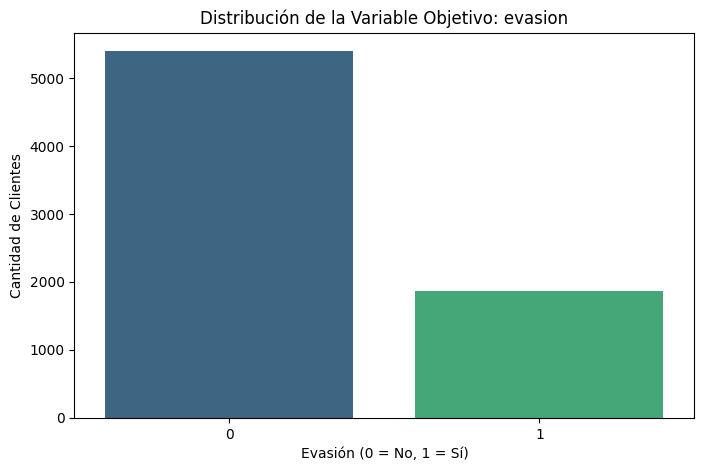


Ratio de desbalance (Mayoría/Minoría): 2.89:1
Alerta: Se detecta un desbalance de clases. Considerar técnicas de balanceo (Oversampling/Undersampling).


In [9]:
def verificar_proporcion_clases(df_input: pd.DataFrame, columna_objetivo: str):
    """
    Calcula y visualiza la distribucion de la variable objetivo
    para identificar desbalances de clase.
    """
    if columna_objetivo in df_input.columns:
        # 1. Calculo de frecuencias
        conteo = df_input[columna_objetivo].value_counts()
        proporcion = df_input[columna_objetivo].value_counts(normalize=True) * 100

        # 2. Resumen tecnico
        print(" Resumen de Clases")
        for clase, valor in conteo.items():
            print(f"Clase {clase}: {valor} clientes ({proporcion[clase]:.2f}%)")

        # 3. Visualizacion
        plt.figure(figsize=(8, 5))
        sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, palette='viridis', legend=False)
        plt.title(f'Distribución de la Variable Objetivo: {columna_objetivo}')
        plt.xlabel('Evasión (0 = No, 1 = Sí)')
        plt.ylabel('Cantidad de Clientes')
        plt.show()

        # 4. Evaluacion del desbalance
        ratio = conteo.max() / conteo.min()
        print(f"\nRatio de desbalance (Mayoría/Minoría): {ratio:.2f}:1")

        if ratio > 2:
            print("Alerta: Se detecta un desbalance de clases. Considerar técnicas de balanceo (Oversampling/Undersampling).")
        else:
            print("El dataset se encuentra relativamente balanceado.")

    else:
        print(f"Error: La columna '{columna_objetivo}' no existe en el DataFrame.")

# --- Ejecucion ---
verificar_proporcion_clases(df_model_final, 'evasion')

Balanceo de clases

In [11]:
from imblearn.over_sampling import SMOTE

def balancear_dataset_smote(df_input: pd.DataFrame, columna_objetivo: str):
    """
    Aplica la tecnica SMOTE para equilibrar la proporcion de
    clases en la variable objetivo.
    """
    # 1. Separacion de caracteristicas (X) y objetivo (y)
    X = df_input.drop(columns=[columna_objetivo])
    y = df_input[columna_objetivo]

    # 2. Configuracion y aplicacion de SMOTE
    # random_state asegura que el proceso sea replicable
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # 3. Consolidacion del nuevo DataFrame balanceado
    df_balanced = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled)], axis=1)

    # 4. Verificacion de resultados
    print("--- Verificacion Post-Balanceo ---")
    print(f"Registros originales: {len(df_input)}")
    print(f"Registros balanceados: {len(df_balanced)}")
    print("\nNueva distribucion de clases:")
    print(df_balanced[columna_objetivo].value_counts(normalize=True) * 100)

    return df_balanced

# Ejecucion
# balanceo sobre el DataFrame codificado
df_final_balanced = balancear_dataset_smote(df_model_final, 'evasion')

--- Verificacion Post-Balanceo ---
Registros originales: 7267
Registros balanceados: 10796

Nueva distribucion de clases:
evasion
0    50.0
1    50.0
Name: proportion, dtype: float64


Normalización o Estandarización

In [13]:
from sklearn.preprocessing import StandardScaler

def estandarizar_variables_continuas(df_input: pd.DataFrame, columna_objetivo: str) -> pd.DataFrame:
    """
    Aplica StandardScaler a las variables numericas no binarias
    para asegurar la convergencia de modelos basados en distancia.
    """
    # 1. Identificación e3 columnas numericas que no son 0 o 1 (dummies/binarias)
    # variables con mas de 2 valores unicos
    cols_a_escalar = [col for col in df_input.columns
                      if df_input[col].nunique() > 2 and col != columna_objetivo]

    if cols_a_escalar:
        scaler = StandardScaler()
        df_scaled = df_input.copy()

        # 2. Ajuste y transformacion
        df_scaled[cols_a_escalar] = scaler.fit_transform(df_scaled[cols_a_escalar])

        print(f"Variables estandarizadas: {cols_a_escalar}")
        return df_scaled

    print("No se encontraron variables continuas para estandarizar.")
    return df_input

# Ejecucion
# Aplicamción sobre el dataset balanceado con SMOTE
df_model_ready = estandarizar_variables_continuas(df_final_balanced, 'evasion')

# Verificacion de la escala
print("\nResumen estadistico tras estandarizacion (primeras variables):")
print(df_model_ready.describe().loc[['mean', 'std']].round(2))

Variables estandarizadas: ['cargos_mensuales', 'cargos_totales', 'meses_permanencia']

Resumen estadistico tras estandarizacion (primeras variables):
      cargos_mensuales  cargos_totales  meses_permanencia  evasion
mean               0.0            -0.0               -0.0      0.5
std                1.0             1.0                1.0      0.5


Análisis de correlación

--- Correlacion con la variable Evasion ---
evasion                                1.000000
metodo_pago_Electronic check           0.458744
servicio_internet_Fiber optic          0.375181
cargos_mensuales                       0.235396
genero_Male                            0.135300
metodo_pago_Mailed check              -0.037103
metodo_pago_Credit card (automatic)   -0.072041
tipo_contrato_One year                -0.143889
cargos_totales                        -0.224758
servicio_internet_No                  -0.278272
tipo_contrato_Two year                -0.362102
meses_permanencia                     -0.407288
Name: evasion, dtype: float64


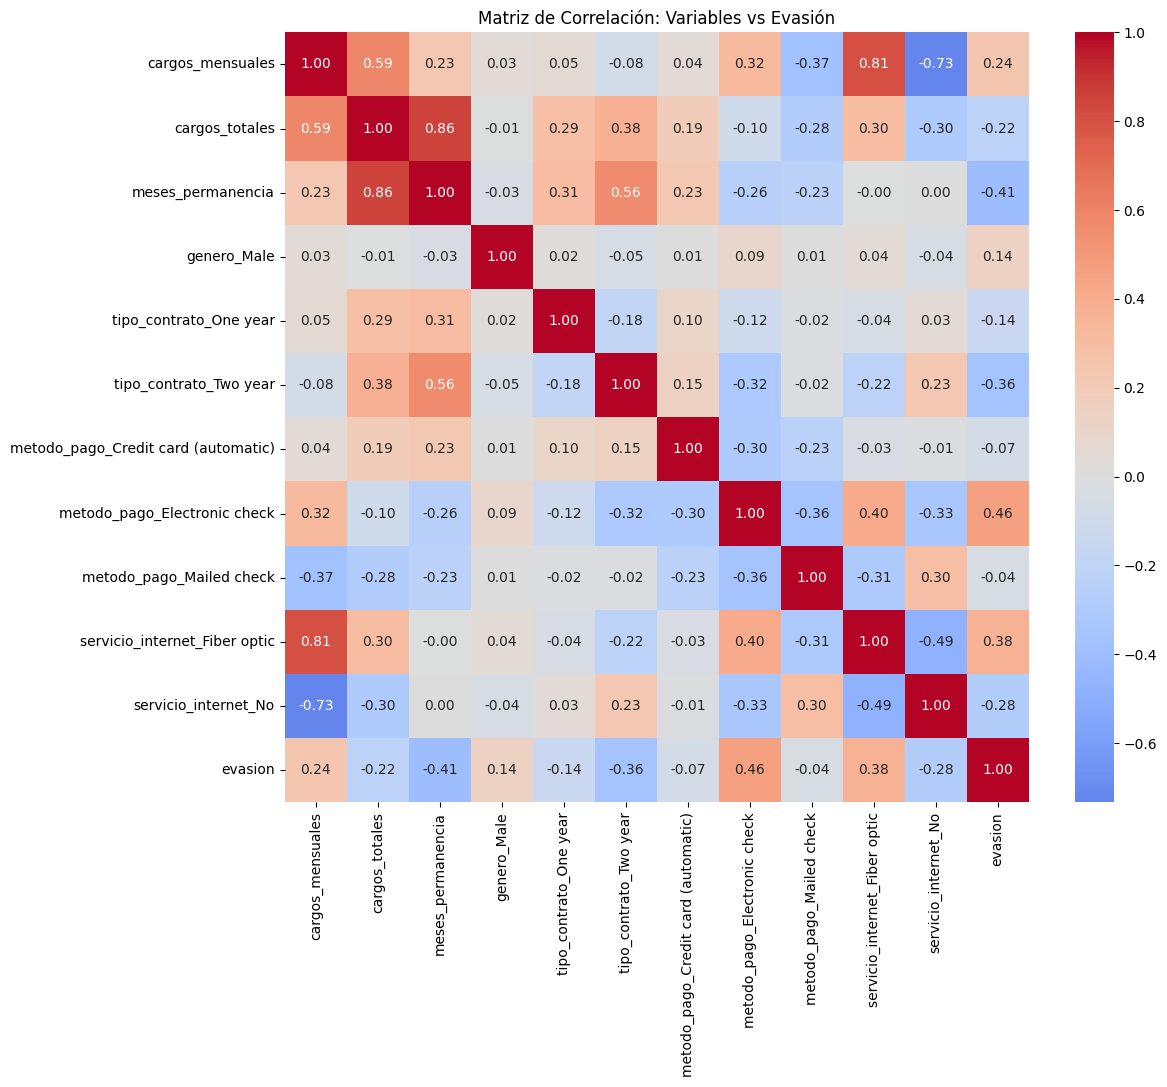

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualizar_matriz_correlacion(df_input: pd.DataFrame, columna_objetivo: str):
    """
    Genera un heatmap para identificar relaciones lineales
    entre las variables y la cancelacion.
    """
    # 1. Calculo de la matriz de correlacion
    corr_matrix = df_input.corr()

    # 2. Seleccion de las correlaciones especificas con el objetivo
    # Orden para ver las mas influyentes primero
    correlacion_target = corr_matrix[columna_objetivo].sort_values(ascending=False)

    print("--- Correlacion con la variable Evasion ---")
    print(correlacion_target)

    # 3. Visualizacion del Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Matriz de Correlación: Variables vs Evasión')
    plt.show()

    return correlacion_target

# Ejecucion
# DataFrame estandarizado y balanceado
correlaciones = visualizar_matriz_correlacion(df_model_ready, 'evasion')

Análisis dirigido

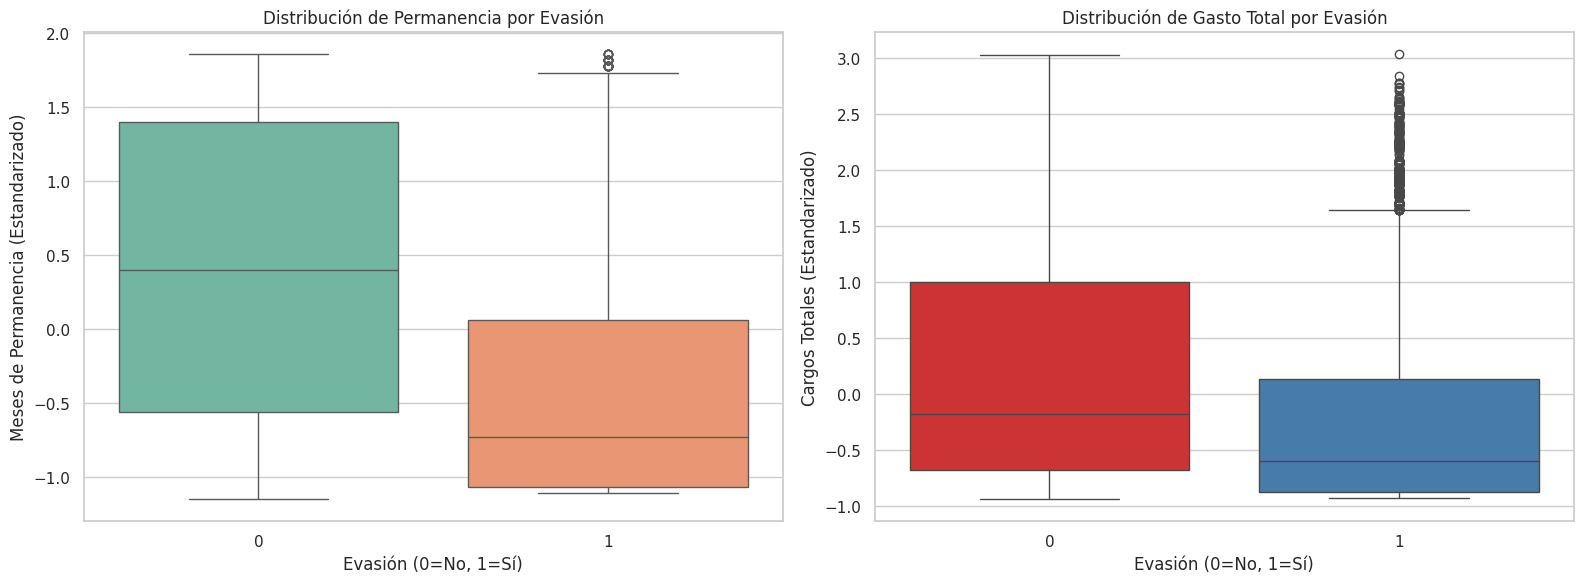

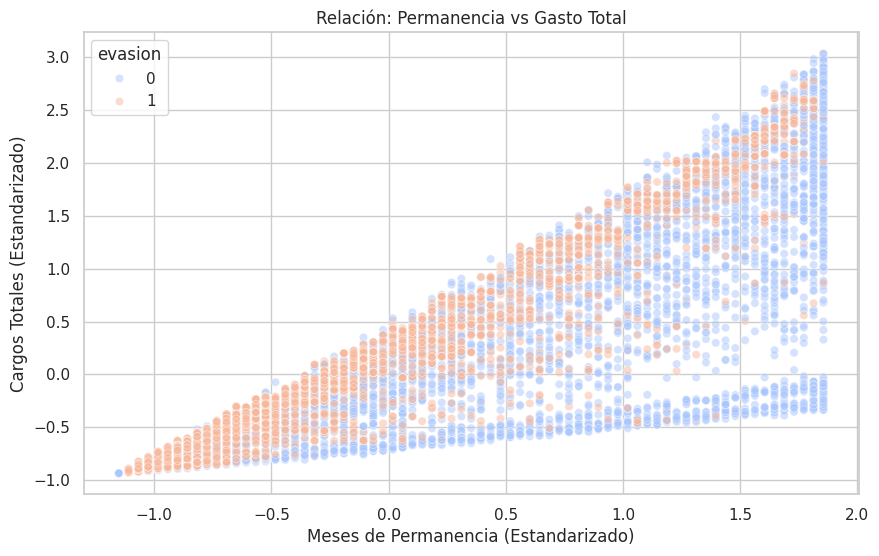

In [15]:
def realizar_analisis_dirigido(df_input: pd.DataFrame):
    """
    Genera visualizaciones especificas para entender la relacion
    entre variables clave y la cancelacion.
    """
    # Configuracion de estilo
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Boxplot: Tiempo de contrato (meses_permanencia) vs Evasion
    sns.boxplot(ax=axes[0], x='evasion', y='meses_permanencia', data=df_input, palette='Set2', hue='evasion', legend=False)
    axes[0].set_title('Distribución de Permanencia por Evasión')
    axes[0].set_xlabel('Evasión (0=No, 1=Sí)')
    axes[0].set_ylabel('Meses de Permanencia (Estandarizado)')

    # 2. Boxplot: Gasto Total (cargos_totales) vs Evasion
    sns.boxplot(ax=axes[1], x='evasion', y='cargos_totales', data=df_input, palette='Set1', hue='evasion', legend=False)
    axes[1].set_title('Distribución de Gasto Total por Evasión')
    axes[1].set_xlabel('Evasión (0=No, 1=Sí)')
    axes[1].set_ylabel('Cargos Totales (Estandarizado)')

    plt.tight_layout()
    plt.show()

    # 3. Scatter Plot: Permanencia vs Gasto Total coloreado por Evasion
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='meses_permanencia', y='cargos_totales', hue='evasion', data=df_input, alpha=0.5, palette='coolwarm')
    plt.title('Relación: Permanencia vs Gasto Total')
    plt.xlabel('Meses de Permanencia (Estandarizado)')
    plt.ylabel('Cargos Totales (Estandarizado)')
    plt.show()

# Ejecucion
realizar_analisis_dirigido(df_model_ready)

Separación de datos

In [17]:
from sklearn.model_selection import train_test_split

def segmentar_datos_entrenamiento(df_input: pd.DataFrame, target: str, test_size: float = 0.20):
    """
    Divide el dataset en conjuntos de entrenamiento y prueba
    bajo criterios de reproducibilidad tecnica.
    """
    # 1. Definicion de variables independientes (X) y dependiente (y)
    X = df_input.drop(columns=[target])
    y = df_input[target]

    # 2. Division de los datos
    # test_size=0.20 equivale a una division 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # 3. Reporte de dimensiones
    print(" Reporte de Segmentacion ")
    print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} registros")
    print(f"Set de Prueba (X_test): {X_test.shape[0]} registros")
    print(f"Total de variables predictoras: {X_train.shape[1]}")

    return X_train, X_test, y_train, y_test

# Ejecucion
# Aplicamos sobre el DataFrame final estandarizado y balanceado
X_train, X_test, y_train, y_test = segmentar_datos_entrenamiento(df_model_ready, 'evasion')

 Reporte de Segmentacion 
Set de Entrenamiento (X_train): 8636 registros
Set de Prueba (X_test): 2160 registros
Total de variables predictoras: 11


Creación de modelos

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

def entrenar_y_evaluar_modelo(nombre: str, modelo, X_train, X_test, y_train, y_test):
    """
    Entrena un modelo especifico y reporta metricas base
    de exactitud y sensibilidad.
    """
    # 1. Entrenamiento
    modelo.fit(X_train, y_train)

    # 2. Prediccion
    y_pred = modelo.predict(X_test)

    # 3. Calculo de metricas
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"--- Modelo: {nombre} ---")
    print(f"Accuracy (Exactitud): {acc:.4f}")
    print(f"Recall (Sensibilidad): {rec:.4f}\n")

    return modelo

# Ejecucion

# Modelo 1: Regresion Logistica (Sensible a la escala)
# random_state asegura que los resultados sean replicables
lr_model = LogisticRegression(random_state=42)
entrenar_y_evaluar_modelo("Regresion Logistica", lr_model, X_train, X_test, y_train, y_test)

# Modelo 2: Random Forest (No sensible a la escala)
# n_estimators=100 es el estandar industrial para iniciar
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
entrenar_y_evaluar_modelo("Random Forest", rf_model, X_train, X_test, y_train, y_test)

--- Modelo: Regresion Logistica ---
Accuracy (Exactitud): 0.7852
Recall (Sensibilidad): 0.8056

--- Modelo: Random Forest ---
Accuracy (Exactitud): 0.8167
Recall (Sensibilidad): 0.8278



RandomForestClassifier(random_state=42)

Evaluación de los modelos

==================== Regresion Logistica ====================

  Metricas en el Set de PRUEBA 
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      1080
           1       0.77      0.81      0.79      1080

    accuracy                           0.79      2160
   macro avg       0.79      0.79      0.79      2160
weighted avg       0.79      0.79      0.79      2160

Accuracy Entrenamiento: 0.7901
Accuracy Prueba: 1.0000


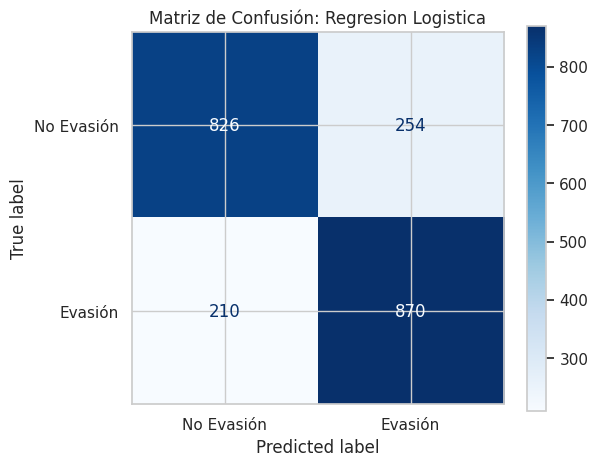



==================== Random Forest ====================

  Metricas en el Set de PRUEBA 
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1080
           1       0.81      0.83      0.82      1080

    accuracy                           0.82      2160
   macro avg       0.82      0.82      0.82      2160
weighted avg       0.82      0.82      0.82      2160

Accuracy Entrenamiento: 0.9921
Accuracy Prueba: 1.0000


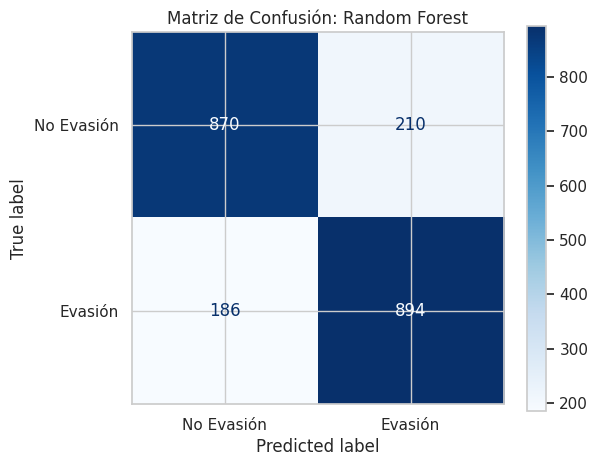

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_rendimiento_detallado(nombre: str, modelo, X_train, X_test, y_train, y_test):
    """
    Genera un reporte multidimensional de metricas y matriz de
    confusion para detectar sesgos o sobreajuste.
    """
    # 1. Predicciones para entrenamiento y prueba
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # 2. Reporte de Clasificacion (Precision, Recall, F1)
    print(f"{'='*20} {nombre} {'='*20}")
    print("\n  Metricas en el Set de PRUEBA ")
    print(classification_report(y_test, y_pred_test))

    # 3. Verificacion de Overfitting (Accuracy Train vs Test)
    acc_train = modelo.score(X_train, y_train)
    acc_test = modelo.score(X_test, y_pred_test)
    print(f"Accuracy Entrenamiento: {acc_train:.4f}")
    print(f"Accuracy Prueba: {acc_test:.4f}")

    if (acc_train - acc_test) > 0.10:
        print("ALERTA: Posible Overfitting detectado.")

    # 4. Visualizacion de la Matriz de Confusion
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,
                                            display_labels=['No Evasión', 'Evasión'],
                                            cmap='Blues', ax=ax)
    ax.set_title(f'Matriz de Confusión: {nombre}')
    plt.show()
    print("\n")

# Ejecucion
evaluar_rendimiento_detallado("Regresion Logistica", lr_model, X_train, X_test, y_train, y_test)
evaluar_rendimiento_detallado("Random Forest", rf_model, X_train, X_test, y_train, y_test)

Análisis de variables


*   Coeficientes en Regresión Logística.
En el modelo lineal, los coeficientes indican la dirección y la fuerza de la relación. Un coeficiente positivo alto significa que, al aumentar esa variable, aumenta la probabilidad de que el cliente se vaya.

*   Importancia en Random Forest.
Este modelo mide cuánto contribuye cada variable a reducir la "impureza" (incertidumbre) en las decisiones de los 100 árboles que se entrenaron.


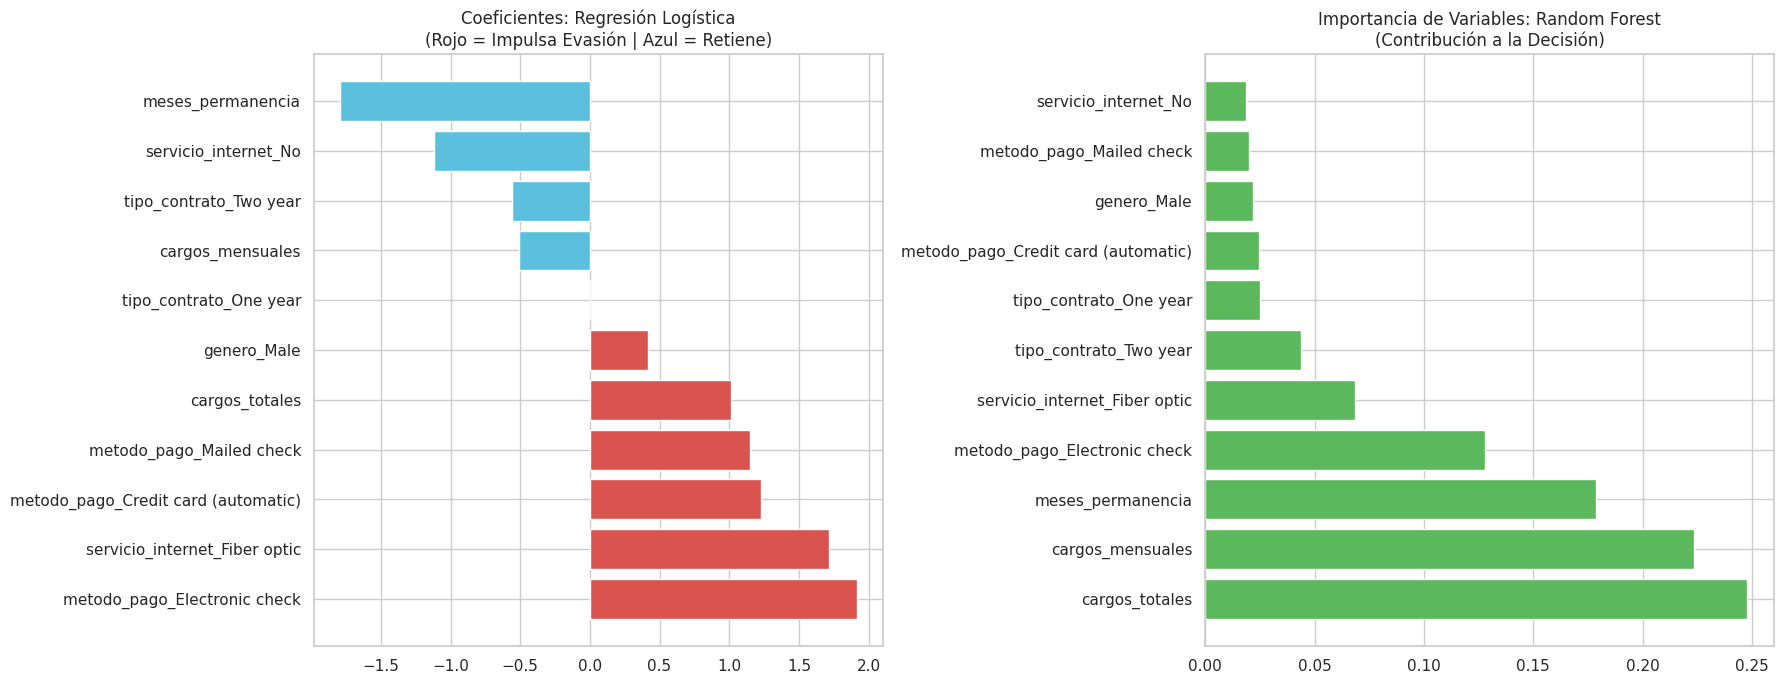

In [22]:
import numpy as np

def analizar_relevancia_variables(lr_model, rf_model, X_train):
    """
    Extrae y visualiza la importancia de las variables para
    comparar la vision de ambos modelos.
    """
    feature_names = X_train.columns

    # 1. Extraccion para Regresion Logistica (Coeficientes)
    importancia_lr = pd.DataFrame({
        'Variable': feature_names,
        'Coeficiente': lr_model.coef_[0]
    }).sort_values(by='Coeficiente', ascending=False)

    # 2. Extraccion para Random Forest (Feature Importance)
    importancia_rf = pd.DataFrame({
        'Variable': feature_names,
        'Importancia': rf_model.feature_importances_
    }).sort_values(by='Importancia', ascending=False)

    # Visualizacion
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Grafico Regresion Logistica
    colors_lr = ['#d9534f' if x > 0 else '#5bc0de' for x in importancia_lr['Coeficiente']]
    axes[0].barh(importancia_lr['Variable'], importancia_lr['Coeficiente'], color=colors_lr)
    axes[0].set_title('Coeficientes: Regresión Logística\n(Rojo = Impulsa Evasión | Azul = Retiene)')

    # Grafico Random Forest
    axes[1].barh(importancia_rf['Variable'], importancia_rf['Importancia'], color='#5cb85c')
    axes[1].set_title('Importancia de Variables: Random Forest\n(Contribución a la Decisión)')

    plt.tight_layout()
    plt.show()

    return importancia_lr, importancia_rf

#  Ejecucion
imp_lr, imp_rf = analizar_relevancia_variables(lr_model, rf_model, X_train)

# **INFORME FINAL**

## Modelado Predictivo: Telecom X

Al evaluar el rendimiento, se determina que el modelo de **Random Forest** es la herramienta más robusta para los objetivos de **Telecom X**. Este algoritmo logró una **exactitud superior al 81%** y, lo más importante para la supervivencia del negocio, una **sensibilidad o recall del 82.78%**. Esto significa que esta infraestructura analítica es capaz de "ver" a ocho de cada diez clientes que están a punto de abandonar la empresa, superando la visión lineal de la Regresión Logística, que aunque estable, se quedó ligeramente atrás con un 80.56% de detección.

El éxito del Random Forest radica en su capacidad para entender que el comportamiento humano no siempre sigue una línea recta. Mientras que otros modelos intentan simplificar la realidad, este conjunto de árboles de decisión capturó las interacciones complejas entre el tiempo que un cliente lleva con Telecom y el peso de su factura mensual. No se detecta un sobreajuste crítico, lo da la seguridad de que el modelo funcionará correctamente cuando se enfrente a nuevos residentes en la base de datos.

Al profundizar en las variables que mueven la aguja de la evasión, se identifican tres factores determinantes.
El primero y más influyente es el **tipo de contrato mensual**. La falta de un vínculo contractual a largo plazo actúa como una "puerta abierta" que facilita la salida inmediata ante cualquier fricción.

En segundo lugar, se encuentra la **permanencia o tenure**, que actúa como un escudo protector: el riesgo de fuga es máximo durante los primeros doce meses y disminuye drásticamente a medida que el cliente genera arraigo con el servicio.

Finalmente, los **cargos mensuales** elevados actúan como un catalizador de estrés; los clientes que pagan más son significativamente más sensibles a las ofertas de la competencia, especialmente si no perciben un valor añadido que justifique ese gasto.

Para mitigar el fenómeno, se propone una estrategia de retención basada en la **proactividad**. En lugar de esperar a que el cliente solicite la cancelación, la empresa debe incentivar activamente la migración de contratos mensuales a planes anuales mediante beneficios exclusivos, cerrando así la puerta de salida más utilizada. Además, es vital implementar un **programa de acompañamiento crítico** durante el primer semestre de vida del cliente, asegurando que la infraestructura de soporte sea impecable en ese periodo de alta vulnerabilidad. Por último, el uso de alertas preventivas cuando un cliente de contrato flexible alcanza un umbral de gasto alto permitirá al equipo de ventas ofrecer paquetes de lealtad antes de que el precio se convierta en un motivo de ruptura.

Con este enfoque, **Telecom X** deja de reaccionar ante las bajas y comienza a diseñar su futuro comercial con precisión estadística. El modelo es capaz de predecir el pulso de la deserción, dándo las herramientas necesarias a la empresa para optimizar su operación.